# ATHENA CAMM Hackathon 01
## Boundary Detection + Atom Finding

**September 2026**

A scientific algorithm should not only work once. It should be **explainable, testable, fast, consistent, and robust**.

### Challenge 1 — Boundary Detection
- Dataset: **SiSb**
- Input: **12 HAADF-STEM images**
- Goal: detect the crystalline–amorphous boundary

### Challenge 2 — Atom Finding
- Dataset: **YBCO**
- Input: atomic-resolution STEM images
- Goal: return atomic-column coordinates

All helper functions are kept in:

```text
utils.py
```

The notebook stays focused on the two functions you are asked to improve.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kbarakati/athena_camm_hackathon/blob/k4my4r/docs/day_16_11092026/boundary_detection.ipynb)

## 1. Setup

In [1]:
# %pip install -q pyTEMlib ipympl

In [2]:
# # Download only the files needed for this challenge
# !git clone -q --filter=blob:none --no-checkout -b k4my4r \
#     https://github.com/kbarakati/athena_camm_hackathon.git athena

# %cd athena
# !git sparse-checkout init --cone
# !git sparse-checkout set docs/day_16_11092026
# !git checkout -q

# %cd docs/day_16_11092026


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage

from utils import (
    resolve_data_dir,
    list_emd_files,
    robust_normalize,
    load_haadf,
    show_image_grid,
    plot_ground_truth_grid,
    plot_boundary_result,
    evaluate_against_ground_truth,
    summarize_accuracy,
    evaluate_robustness,
    summarize_robustness,
    evaluate_speed,
    summarize_speed,
    plot_atom_result,
    validate_atom_output,
    atom_repeatability,
    atom_noise_robustness,
    atom_photometric_robustness,
)

You don't have gwyfile installed.     If you wish to open .gwy files, you will need to      install it (pip install gwyfile) before attempting.
Symmetry functions of spglib enabled


In [4]:
DATA_DIR = resolve_data_dir()

SISB_DIR = DATA_DIR / "SiSb"
YBCO_DIR = DATA_DIR / "YBCO"
GT_DIR = DATA_DIR / "SiSb_ground_truth"

print("DATA_DIR:", DATA_DIR)
print("SiSb:", SISB_DIR.exists())
print("YBCO:", YBCO_DIR.exists())
print("SiSb ground truth:", GT_DIR.exists())

DATA_DIR: /Users/kbarakat/Library/CloudStorage/OneDrive-UniversityofTennessee 2/vs_code/2026/athena_camm_hackathon/docs/day_16_11092026/data
SiSb: True
YBCO: True
SiSb ground truth: True


# Challenge 1 — Boundary Detection

## Goal

Write:

```python
boundary = detect_boundary(image)
```

The function must return a **2D boolean array with the same shape as the input image**.

`True` means that pixel belongs to the predicted crystalline–amorphous boundary.

## 2. Load the SiSb challenge images

In [5]:
all_sisb_files = list_emd_files(SISB_DIR)

N_SISB = 12
sisb_files = all_sisb_files[:N_SISB]

sisb_images = [
    load_haadf(file)
    for file in sisb_files
]

sisb_titles = [
    file.stem.split("-")[0].strip()
    for file in sisb_files
]

print(f"Using {len(sisb_files)} SiSb images")

Using 12 SiSb images


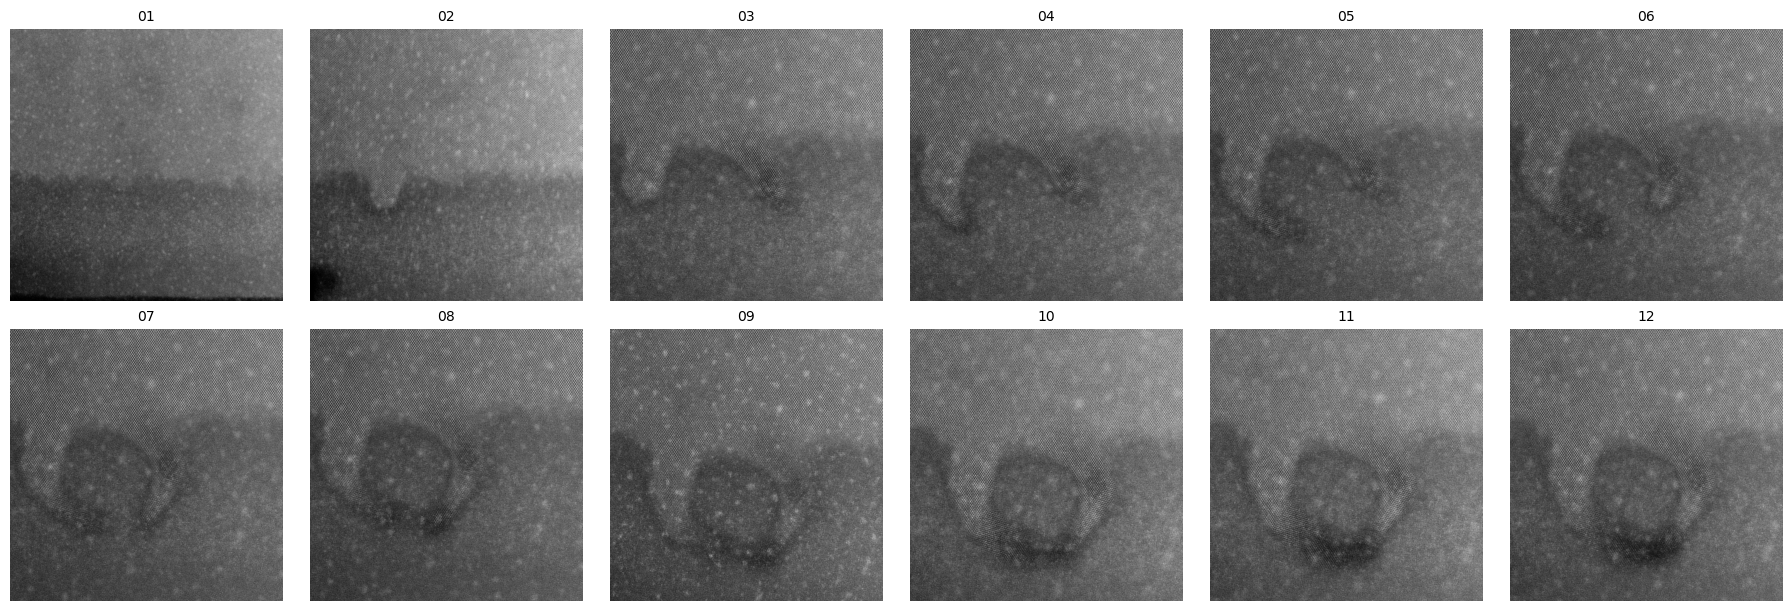

In [6]:
show_image_grid(
    sisb_images,
    titles=sisb_titles,
    rows=2,
)

### Human ground truth

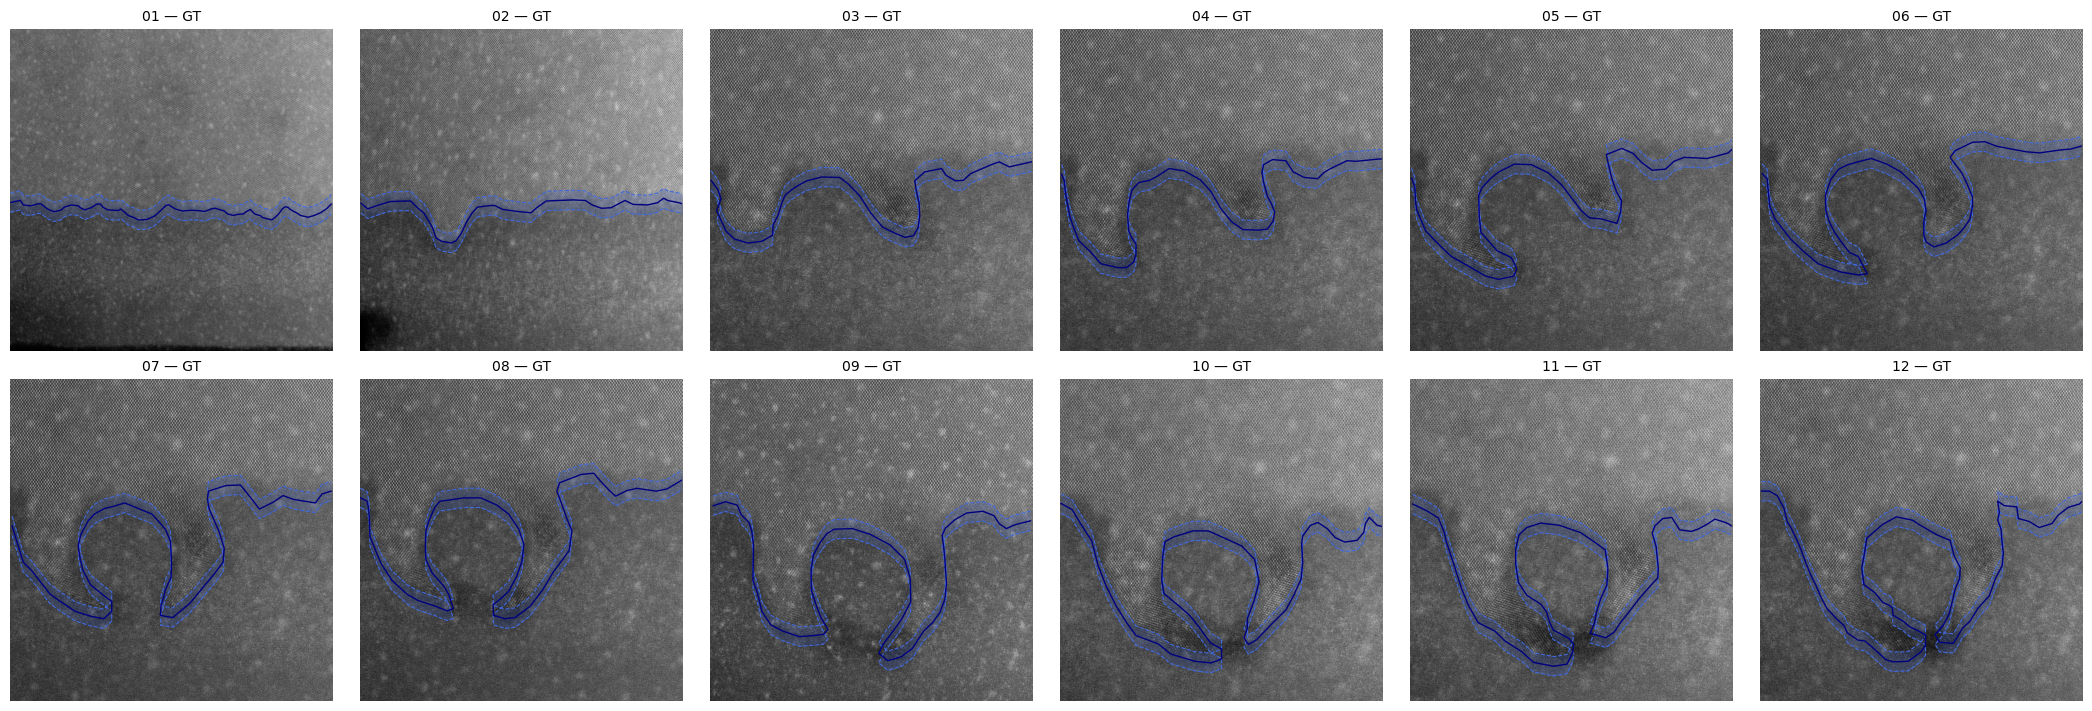

In [7]:
plot_ground_truth_grid(
    sisb_images,
    sisb_files,
    sisb_titles,
    GT_DIR,
    rows=2,
)

## 3. Build your boundary detector

A simple texture-based baseline is provided.

You may completely replace the code between the two markers.  
Do **not** change the function name, input, or required output format.

In [56]:
def detect_boundary(image):

    # ============================================================
    # ===== YOUR CODE START — CHANGE CODE BELOW THIS LINE =====
    # ============================================================

    # 1. Normalize
    x = robust_normalize(image)

    # 2. Estimate local texture using local variance
    sigma_texture = 7

    local_mean = ndimage.gaussian_filter(
        x,
        sigma=sigma_texture
    )

    local_mean_squared = ndimage.gaussian_filter(
        x**2,
        sigma=sigma_texture
    )

    local_variance = np.maximum(
        local_mean_squared - local_mean**2,
        0
    )

    # 3. Smooth the texture map
    texture = ndimage.gaussian_filter(
        local_variance,
        sigma=1
    )

    # 4. Separate the two texture regimes
    threshold = np.median(texture)
    phase_mask = texture > threshold

    # 5. Clean the phase segmentation
    phase_mask = ndimage.binary_opening(
        phase_mask,
        iterations=2
    )

    phase_mask = ndimage.binary_closing(
        phase_mask,
        iterations=1
    )

    # 6. Extract the interface
    dilated = ndimage.binary_dilation(
        phase_mask,
        iterations=1
    )

    eroded = ndimage.binary_erosion(
        phase_mask,
        iterations=1
    )

    boundary = dilated ^ eroded

    # ============================================================
    # ===== YOUR CODE END — DO NOT CHANGE CODE BELOW HERE =====
    # ============================================================

    return boundary.astype(bool)

## 4. Test one image visually

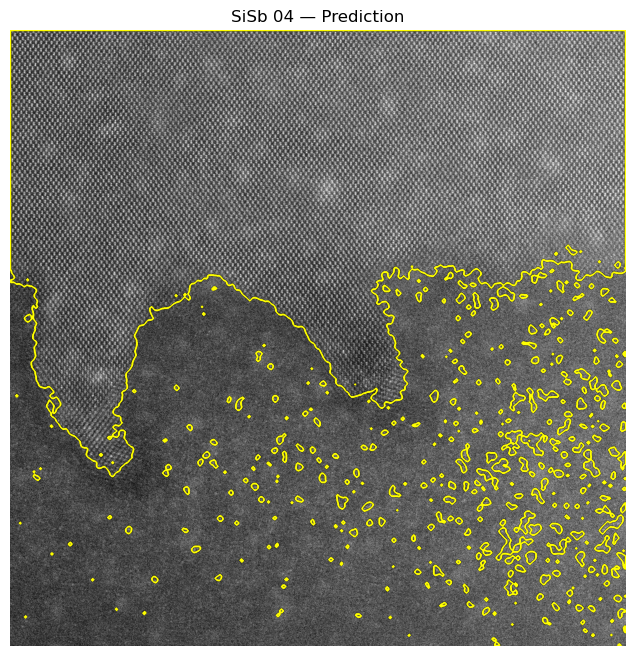

In [58]:
example_index = 3

image = sisb_images[example_index]
boundary = detect_boundary(image)

plot_boundary_result(
    image,
    boundary,
    title=f"SiSb {sisb_titles[example_index]} — Prediction",
)

## 5. Challenge 1 evaluation

We evaluate only three things:

### 1. Accuracy against human ground truth
Predictions are compared with the hand-drawn boundary using a spatial tolerance. Exact single-pixel agreement is not required.

Primary metric: **F1 @ 5 px tolerance**

### 2. Robustness
The same detector is tested after controlled perturbations:
- Gaussian noise
- Gaussian blur
- brightness change
- contrast change
- inclined intensity background

Every perturbed prediction is compared with the **same human ground truth**.

### 3. Speed
Only `detect_boundary(image)` is timed. File loading, plotting, and scoring are excluded.

### Test 1 — Accuracy against ground truth

In [ ]:
accuracy_results = evaluate_against_ground_truth(
    detect_boundary,
    sisb_images,
    sisb_files,
    sisb_titles,
    GT_DIR,
    tolerance_px=10,
)

accuracy_results

In [ ]:
summarize_accuracy(
    accuracy_results
)

### Test 2 — Robustness

In [ ]:
robustness_results = evaluate_robustness(
    detect_boundary,
    sisb_images,
    sisb_files,
    sisb_titles,
    GT_DIR,
    tolerance_px=5,
    max_images=4,
)

robustness_summary = summarize_robustness(
    robustness_results
)

robustness_summary

Interpretation:

- `mean_f1`: accuracy under that condition
- `mean_boundary_error_px`: average symmetric distance to the human boundary
- `f1_drop_from_clean`: performance lost relative to the clean images

**Smaller F1 drop is better.**

### Test 3 — Speed

In [ ]:
speed_results = evaluate_speed(
    detect_boundary,
    sisb_images,
    repeats=5,
)

summarize_speed(
    speed_results
)

# Challenge 2 — Atom Finding in YBCO

## Goal

Write:

```python
positions = find_atoms(image)
```

The function must return a NumPy array of shape `(N, 2)`.

Each row is:

```text
[y, x]
```

in pixel coordinates.

## 6. Load YBCO

In [ ]:
ybco_files = list_emd_files(YBCO_DIR)

ybco_images = [
    load_haadf(file)
    for file in ybco_files
]

ybco_titles = [
    file.stem
    for file in ybco_files
]

print(f"Found {len(ybco_images)} YBCO images")

if ybco_images:
    show_image_grid(
        ybco_images,
        titles=[
            str(i + 1)
            for i in range(len(ybco_images))
        ],
        rows=1 if len(ybco_images) > 1 else 1,
    )

## 7. Build your atom finder

A simple local-maximum baseline is provided.

You may completely replace the code between the two markers.

In [ ]:
def find_atoms(image):

    # ============================================================
    # ===== YOUR CODE START — CHANGE CODE BELOW THIS LINE =====
    # ============================================================

    # 1. Normalize
    x = robust_normalize(image)

    # 2. Smooth
    smooth = ndimage.gaussian_filter(
        x,
        sigma=1.0
    )

    # 3. Find local maxima
    neighborhood = 5

    local_max = (
        smooth
        == ndimage.maximum_filter(
            smooth,
            size=neighborhood,
            mode="reflect",
        )
    )

    # 4. Keep only bright maxima
    intensity_threshold = np.percentile(
        smooth,
        97.0,
    )

    peaks = (
        local_max
        & (smooth >= intensity_threshold)
    )

    # 5. Convert peaks to [y, x]
    positions = np.argwhere(peaks)

    # ============================================================
    # ===== YOUR CODE END — DO NOT CHANGE CODE BELOW HERE =====
    # ============================================================

    return np.asarray(
        positions
    ).reshape(-1, 2).astype(float)

## 8. Test one YBCO image visually

In [ ]:
if ybco_images:

    atom_example_index = 0

    atom_positions = find_atoms(
        ybco_images[atom_example_index]
    )

    validate_atom_output(
        ybco_images[atom_example_index],
        atom_positions,
    )

    plot_atom_result(
        ybco_images[atom_example_index],
        atom_positions,
        title="YBCO atom finding",
    )

## 9. Challenge 2 engineering tests

Until atom ground truth is added, these measure **consistency and robustness**, not true atom-detection accuracy.

In [ ]:
if ybco_images:
    atom_noise_results = atom_noise_robustness(
        find_atoms,
        ybco_images,
        noise_levels=(0.01, 0.03, 0.05, 0.10),
        tolerance=2.0,
    )

atom_noise_results

In [ ]:
if ybco_images:
    atom_photometric_results = atom_photometric_robustness(
        find_atoms,
        ybco_images,
        tolerance=2.0,
    )

atom_photometric_results

In [ ]:
if ybco_images:

    atom_speed_results = evaluate_speed(
        find_atoms,
        ybco_images,
        repeats=5,
    )

summarize_speed(
        atom_speed_results
    )

# 10. Reflection

At the end of the session, be ready to explain:

1. What approach did you use?
2. Which parameters matter most?
3. Where does it fail?
4. What would you improve next?
5. If AI helped write code, what did it generate?
6. What did you personally change?

> A good scientific algorithm is not just one that gives a nice picture.  
> You should be able to explain **how accurate, robust, and fast it is**.